In [18]:
import os
from logging import INFO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow as pa
import pyarrow.compute as pc
from typing import Optional, List
import random

from flwr.common import log

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# srun -w mauao -c 5 --partition=interactive --pty bash
# srun -w ngongotaha -c 5 --partition=interactive --pty bash
# poetry shell
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao
# ssh -L 8889:localhost:8889 ls985@ngongotaha
HOME_DIR = Path(f"{os.getenv('HOME', '')}")

In [19]:
RESULTS_DIR = Path(f"{HOME_DIR}/projects/pollen_worker/results")

In [20]:
FRAMEWORKS = ['Pollen', 'Parrot', 'Flower', 'FedScale', 'Flute'] # New labels

In [21]:
DATASETS = ['TG', 'IC', 'SR', 'MLM']

In [22]:
DATASETS_FLWR = {
    'openimage': 'IC',
    'google_speech': 'SR',
    'shakespeare_memory': 'TG',
    'reddit': 'MLM',
}

DATASETS_FEDSCALE = {
    'openimage': 'IC',
    'google_speech': 'SR',
    'shakespeare': 'TG',
    'reddit': 'MLM',
}

DATASETS_FLUTE = {
    'openImg': 'IC',
    'google_speech': 'SR',
    'shakespeare': 'TG',
    'reddit': 'MLM',
}

In [23]:
HARDWARE_SETTINGS = {
    1: '1 GPU',
    2: '1+3 GPUs',
}

In [24]:
N_TOTAL_ROUNDS = 5_000

In [25]:
SCALES = {
    'IC': {
        100: 'Medium Scale',
        1_000: 'Large Scale',
        10_000: 'Very Large Scale',
    },
    'SR': {
        100: 'Medium Scale',
        1_000: 'Large Scale',
        2_000: 'Very Large Scale',
    },
    'TG': {
        100: 'Medium Scale',
        1_000: 'Large Scale',
        10_000: 'Very Large Scale',
    },
    'MLM': {
        100: 'Medium Scale',
        1_000: 'Large Scale',
    },
}

In [26]:
TEXTURES = ['', '.', 'x', 'O', '/', '*', '|']
COLORS = [
    sns.color_palette('colorblind')[3],
    sns.color_palette('colorblind')[1],
    sns.color_palette('colorblind')[2],
    sns.color_palette('colorblind')[0],
    sns.color_palette('colorblind')[7],
    sns.color_palette('colorblind')[4],
    sns.color_palette('colorblind')[5],
]

In [27]:
def error_bar_fn_std_based(x) -> tuple[float, float]:
    return (np.sum(x)-np.sqrt(N_TOTAL_ROUNDS*(5*np.std(x))**2), np.sum(x)+np.sqrt(N_TOTAL_ROUNDS*(5*np.std(x))**2))

In [28]:
def error_bar_fn_min_max(x) -> tuple[float, float]:
    return (N_TOTAL_ROUNDS*np.min(x), N_TOTAL_ROUNDS*np.max(x))

In [29]:
def read_logs_flwr(log_file_path: Path) -> Optional[pa.Table]:
    """Reads the log file and returns a pandas dataframe with the data."""
    # Init data for the table
    hardware_setting = 0 # 1 or 2
    n_clients_per_round = 0
    round_numbers: List[int] = []
    start_timestamp: List[pd.Timestamp] = []
    end_timestamp: List[pd.Timestamp] = []
    previous_timestamp: Optional[pd.Timestamp] = None
    # Opening log file
    with open(log_file_path, 'r') as f:
        lines = f.readlines()
    while previous_timestamp is None:
        line = lines.pop(0)
        if line.startswith('[') and 'global_state_accessor.cc:356:' not in line.split(' '):
            strings = line.split(' ')
            while '' in strings:
                strings.remove('')
            # Reading first timestamp
            date = strings[0].replace('[', '')
            time = strings[1].split(']')[0]
            previous_timestamp = pd.to_datetime(f"{date} {time}", format="%Y-%m-%d %H:%M:%S,%f")
            # Reading dataset
            dataset = DATASETS_FLWR[strings[5]]
            # Reading framework
            framework = 'Flower' if log_file_path.name.startswith('R') else 'Pollen-{}'.format(strings[13].split("=")[1].upper().replace("\n", ""))
            framework = 'Parrot' if framework == 'Pollen-LLB' else framework
            framework = 'Pollen' if framework == 'Pollen-LB' else framework
            framework = 'Pollen-BB' if framework == 'Pollen-BU' else framework
    # Reading log file
    cnt = 0
    for line in lines:
        if line.startswith('['):
            strings = line.split(' ')
            while '' in strings:
                strings.remove('')
            
            if hardware_setting == 0:
                if framework == 'Flower' and "\'GPU\':" in strings:
                    idx = strings.index("\'GPU\':")
                    hardware_setting = 1 if int(strings[idx+1].split('.')[0]) == 1 else 2
                elif framework.startswith('P') and ("sending" in strings and "instructions" in strings):
                    hardware_setting = int(strings[8])
            
            if ('fit_round' in strings) and ('strategy' in strings):
                date = strings[0].replace('[', '')
                time = strings[1].split(']')[0]
                last_timestamp = pd.to_datetime(f"{date} {time}", format="%Y-%m-%d %H:%M:%S,%f")
                if n_clients_per_round == 0:
                    n_clients_per_round = int(strings[7])
                round_numbers.append(cnt)
                cnt+=1
                start_timestamp.append(previous_timestamp)
                previous_timestamp = last_timestamp
                end_timestamp.append(last_timestamp)
    # Creating dict to pass to pa.Table builder
    dict_for_table = {
        'rct': [(t1 - t0) for t0, t1 in zip(start_timestamp, end_timestamp)],
        'round': round_numbers,
        'n_clients_per_round': [n_clients_per_round]*len(round_numbers),
        'dataset': [dataset]*len(round_numbers),
        'framework': [framework]*len(round_numbers),
        'hardware_setting': [hardware_setting]*len(round_numbers),
        'is_dropped': [False]*len(round_numbers),
    }
    # Returning pa.Table
    return pa.Table.from_pydict(dict_for_table)
                

In [30]:
def read_logs_fedscale(log_file_path: Path) -> Optional[pa.Table]:
    """Reads the log file and returns a pandas dataframe with the data."""
    # Init data for the table
    hardware_setting = 0 # 1 or 2
    n_clients_per_round = 0
    round_numbers: List[int] = []
    start_timestamp: List[pd.Timestamp] = []
    end_timestamp: List[pd.Timestamp] = []
    is_dropped: List[bool] = []
    previous_timestamp: Optional[pd.Timestamp] = None
    # Opening log file
    with open(log_file_path, 'r') as f:
        lines = f.readlines()
    # Reading first configuration line
    line = lines.pop(0)
    strings = line.split(' ')
    while '' in strings:
        strings.remove('')
    # Reading first timestamp
    date = strings[0] # format is "(mm-dd)"
    time = strings[1] # format is "hh:mm:ss"
    previous_timestamp = pd.to_datetime(f"(2023-{date}) {time}", format="(%Y-(%m-%d)) %H:%M:%S")
    # Reading dataset
    dataset = DATASETS_FEDSCALE[strings[6].split("\'")[1].split("-")[0]]
    # Reading framework
    framework = 'FedScale'
    # Reading the hardware setting
    hardware_setting = len(strings[16].split("\'")[1].split("="))
    # Reading log file
    cnt = 0
    for line in lines:
        to_be_discarded = False
        strings = line.split(' ')
        while '' in strings:
            strings.remove('')
        if 'morons.' in strings:
            to_be_discarded = True
        if ('Empty'  in strings) and ('results'  in strings) and ('from'  in strings) and ('client' in strings):
            to_be_discarded = True
        if '[aggregator.py:543]' in strings and 'round:' in strings:
            date = strings[0] # format is "(mm-dd)"
            time = strings[1] # format is "hh:mm:ss"
            last_timestamp = pd.to_datetime(f"(2023-{date}) {time}", format="(%Y-(%m-%d)) %H:%M:%S")
            if to_be_discarded:
                print(f"Round {cnt} to be discarded due to morons or failed deserilization")
            if n_clients_per_round == 0:
                n_clients_per_round = int(strings[15].replace(',', ''))
            to_be_discarded = False
            round_numbers.append(cnt)
            cnt+=1
            start_timestamp.append(previous_timestamp)
            previous_timestamp = last_timestamp
            end_timestamp.append(last_timestamp)
            is_dropped.append(to_be_discarded)
    # Creating dict to pass to pa.Table builder
    dict_for_table = {
        'rct': [(t1 - t0) for t0, t1 in zip(start_timestamp, end_timestamp)],
        'round': round_numbers,
        'n_clients_per_round': [n_clients_per_round]*len(round_numbers),
        'dataset': [dataset]*len(round_numbers),
        'framework': [framework]*len(round_numbers),
        'hardware_setting': [hardware_setting]*len(round_numbers),
        'is_dropped': is_dropped,
    }
    # Returning pa.Table
    return pa.Table.from_pydict(dict_for_table)

In [31]:
def read_logs_flute(log_file_path: Path):
    """Reads the log file and returns a pandas dataframe with the data."""
    # Init data for the table
    n_clients_per_round = 0
    round_numbers: List[int] = []
    start_timestamp: List[pd.Timestamp] = []
    end_timestamp: List[pd.Timestamp] = []
    previous_timestamp: Optional[pd.Timestamp] = None
    # Opening log file
    with open(log_file_path, 'r') as f:
        lines = f.readlines()
    # Reading the hardware setting
    line = lines.pop(3)
    hardware_setting = 1 if int(line[-2]) == 1 else 2
    # Reading dataset
    line = lines.pop(4)
    strings = line.split(' ')
    dataset = DATASETS_FLUTE[strings[5].replace("\'", "").replace(",", "")]
    # Reading framework
    framework = 'Flute'
    # Reading the first timestamp
    while previous_timestamp is None:
        line = lines.pop(0)
        strings = line.split(' ')
        while '' in strings:
            strings.remove('')
        if ('Assigning' in strings and 'default' in strings and 'values' in strings):
            datestring = line.split(' : ')[0].replace(' ', '-')
            previous_timestamp = pd.to_datetime(datestring, format="%a-%b-%d-%H:%M:%S-%Y")
    # Reading log file
    cnt = 0
    for line in lines:
        strings = line.split(' ')
        if n_clients_per_round == 0:
            if ('Clients' in strings and 'for' in strings and 'round' in strings):
                n_clients_per_round = int(strings[9])
        if 'iteration' in strings:
            datestring = line.split(' : ')[0].replace(' ', '-')
            last_timestamp = pd.to_datetime(datestring, format="%a-%b-%d-%H:%M:%S-%Y")
            round_numbers.append(cnt)
            cnt+=1
            start_timestamp.append(previous_timestamp)
            previous_timestamp = last_timestamp
            end_timestamp.append(last_timestamp)
    # Creating dict to pass to pa.Table builder
    dict_for_table = {
        'rct': [(t1 - t0) for t0, t1 in zip(start_timestamp, end_timestamp)],
        'round': round_numbers,
        'n_clients_per_round': [n_clients_per_round]*len(round_numbers),
        'dataset': [dataset]*len(round_numbers),
        'framework': [framework]*len(round_numbers),
        'hardware_setting': [hardware_setting]*len(round_numbers),
        'is_dropped': [False]*len(round_numbers),
    }
    # Returning pa.Table
    return pa.Table.from_pydict(dict_for_table)

In [32]:
results_table: Optional[pa.Table] = None
for result_file in RESULTS_DIR.glob('*'):
    tmp_table: Optional[pa.Table] = None
    filename = result_file.name
    try:
        if filename.startswith('log'):
            tmp_table = read_logs_fedscale(result_file)
        elif filename.startswith('flute'):
            tmp_table = read_logs_flute(result_file)
        else:
            tmp_table = read_logs_flwr(result_file)
        if tmp_table is not None:
            if results_table is None:
                results_table = tmp_table
            else:
                results_table = pa.concat_tables(
                    [results_table, tmp_table],
                )
    except Exception as e:
        print(f"Error while reading {filename}: {e}")

INFO flwr 2024-01-22 14:38:14,818 | 2798658821.py:21 | For Pollen and TG the mean RCT (100 clients) is 3.815+-3.9065553880624813
INFO flwr 2024-01-22 14:38:14,833 | 2798658821.py:21 | For Pollen and IC the mean RCT (100 clients) is 22.1672+-4.908772164197479
INFO flwr 2024-01-22 14:38:14,845 | 2798658821.py:21 | For Pollen and SR the mean RCT (100 clients) is 25.6764+-6.306352594011851
INFO flwr 2024-01-22 14:38:14,858 | 2798658821.py:21 | For Pollen and MLM the mean RCT (100 clients) is 38.975+-3.5599964887623137


INFO flwr 2024-01-22 14:38:14,874 | 2798658821.py:21 | For Parrot and TG the mean RCT (100 clients) is 15.654+-2.6802768513718878
INFO flwr 2024-01-22 14:38:14,891 | 2798658821.py:21 | For Parrot and IC the mean RCT (100 clients) is 96.4162+-7.940993486963706
INFO flwr 2024-01-22 14:38:14,902 | 2798658821.py:21 | For Parrot and SR the mean RCT (100 clients) is 144.1522+-7.229234756182704
INFO flwr 2024-01-22 14:38:14,913 | 2798658821.py:21 | For Parrot and MLM the mean RCT (100 clients) is 152.7592+-7.925352696252704
INFO flwr 2024-01-22 14:38:14,921 | 2798658821.py:21 | For Flower and TG the mean RCT (100 clients) is 4.3364+-4.565614420863857
INFO flwr 2024-01-22 14:38:14,932 | 2798658821.py:21 | For Flower and IC the mean RCT (100 clients) is 30.159+-4.192674444790581
INFO flwr 2024-01-22 14:38:14,942 | 2798658821.py:21 | For Flower and SR the mean RCT (100 clients) is 28.1508+-5.462898439473317
INFO flwr 2024-01-22 14:38:14,951 | 2798658821.py:21 | For Flower and MLM the mean RCT (1

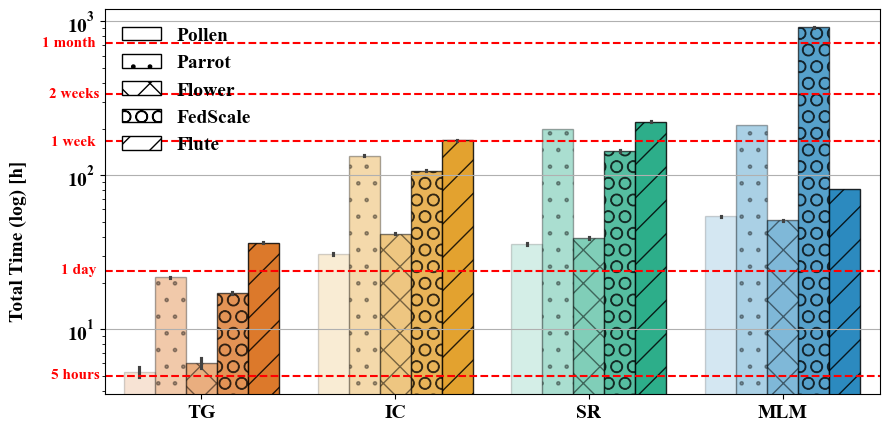

In [35]:
# Drawing bar plots for each dataset, hardware setting = 1 and 100 clients per round
current_hardware_setting = 1
n_clients_per_round = 100
dfs: List[pd.DataFrame] = []
for framework in FRAMEWORKS:
    for dataset in DATASETS:
        random.seed(1337)
        tmp_table = results_table.filter(pc.field('framework') == pc.scalar(framework)).filter(pc.field('dataset') == pc.scalar(dataset)).filter(pc.field('hardware_setting') == pc.scalar(current_hardware_setting)).filter(pc.field('n_clients_per_round') == pc.scalar(n_clients_per_round)).filter(pc.field('is_dropped') == pc.scalar(False))
        try:
            if tmp_table.num_rows != 0:
                tmp_rct = tmp_table.column('rct').to_numpy()[1:].astype('timedelta64[s]').astype(float)
                tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                tmp_dict = {
                    'Round Completion Time [s]': tmp_rct,
                    'Round Completion Time [m]': np.array(tmp_rct)*(1/60),
                    'Round Completion Time [h]': np.array(tmp_rct)*(1/3600),
                    'Round Completion Time [d]': np.array(tmp_rct)*(1/3600)*(1/24),
                    'Framework': [framework]*N_TOTAL_ROUNDS,
                    'Dataset': [dataset]*N_TOTAL_ROUNDS,
                }
                log(INFO, f"For {framework} and {dataset} the mean RCT (100 clients) is {np.mean(tmp_rct)}+-{np.std(tmp_rct)}")
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
        except Exception as e:
            print(e)
df = pd.concat(dfs)
alpha_split = 1.0/(len(df['Framework'].unique())+1)
alphas = [alpha_split*(i+1) for i in range(len(df['Framework'].unique()))]
fig, ax = plt.subplots(figsize=(10, 5))
barplot = sns.barplot(
    data=df,
    x='Dataset',
    y='Round Completion Time [h]',
    order=DATASETS,
    hue='Framework',
    hue_order=FRAMEWORKS,
    errorbar=error_bar_fn_std_based,
    # errorbar=error_bar_fn_min_max,
    estimator=np.sum,
    ax=ax,
    edgecolor='black',
    )
split = (len(df['Framework'].unique())*len(df['Dataset'].unique())-1)
for i, patch in enumerate(ax.patches):
    if i > split:
        patch.set_facecolor('w')
        patch.set_hatch(TEXTURES[(i-split-1)%len(TEXTURES)])
        patch.set_alpha(1.0)
    else:
        patch.set_facecolor(COLORS[i%(len(df['Dataset'].unique()))])
        patch.set_hatch(TEXTURES[i//(len(df['Dataset'].unique()))])
        patch.set_alpha(alphas[i//(len(df['Dataset'].unique()))])
y_axis_position = plt.gca().get_position().x0
plt.axhline(y=5, color='r', linestyle='--')
plt.text(y_axis_position-0.9, 4.8, '5 hours', color='r', fontsize=11)
plt.axhline(y=24, color='r', linestyle='--')
plt.text(y_axis_position-0.85, 23, '1 day', color='r', fontsize=11)
plt.axhline(y=24*7, color='r', linestyle='--')
plt.text(y_axis_position-0.9, (24*7) - 12, '1 week', color='r', fontsize=11)
plt.axhline(y=24*14, color='r', linestyle='--')
plt.text(y_axis_position-0.91, (24*14) - 14, '2 weeks', color='r', fontsize=11)
plt.axhline(y=24*30, color='r', linestyle='--')
plt.text(y_axis_position-0.95, (24*30) - 30, '1 month', color='r', fontsize=11)
y_label = plt.ylabel('Total Time (log) [h]')
y_label.set_weight('bold')
plt.xlabel('')
ax.yaxis.set_label_coords(-0.1, 0.4)
plt.yscale('log')
plt.legend().set_title('')
legend_rect = plt.legend(loc='upper left').get_frame()
legend_rect.set_alpha(0)
plt.grid(axis='y')
plt.savefig('inv_frameworks_singlenode.pdf', format="pdf", dpi=800, bbox_inches='tight')
plt.savefig('inv_frameworks_singlenode.png', format="png", dpi=800, bbox_inches='tight')
plt.show()

INFO flwr 2024-01-22 14:38:39,533 | 948611517.py:20 | For Pollen and TG the mean RCT (100 clients) is 1.6824+-3.1322085243482753
INFO flwr 2024-01-22 14:38:39,547 | 948611517.py:20 | For Pollen and IC the mean RCT (100 clients) is 11.4968+-4.464256910169933


INFO flwr 2024-01-22 14:38:39,561 | 948611517.py:20 | For Pollen and SR the mean RCT (100 clients) is 17.5866+-6.310760686319835
INFO flwr 2024-01-22 14:38:39,572 | 948611517.py:20 | For Pollen and MLM the mean RCT (100 clients) is 22.73+-4.163063775634479
INFO flwr 2024-01-22 14:38:39,586 | 948611517.py:20 | For Parrot and TG the mean RCT (100 clients) is 3.1402+-1.433926065039617
INFO flwr 2024-01-22 14:38:39,600 | 948611517.py:20 | For Parrot and IC the mean RCT (100 clients) is 26.0102+-4.7111459285401045
INFO flwr 2024-01-22 14:38:39,628 | 948611517.py:20 | For Parrot and SR the mean RCT (100 clients) is 42.8758+-6.253125167466266
INFO flwr 2024-01-22 14:38:39,648 | 948611517.py:20 | For Parrot and MLM the mean RCT (100 clients) is 45.5438+-6.59736929086132
INFO flwr 2024-01-22 14:38:39,661 | 948611517.py:20 | For Flower and TG the mean RCT (100 clients) is 4.7534+-2.2640204151023027
INFO flwr 2024-01-22 14:38:39,674 | 948611517.py:20 | For Flower and IC the mean RCT (100 clients)

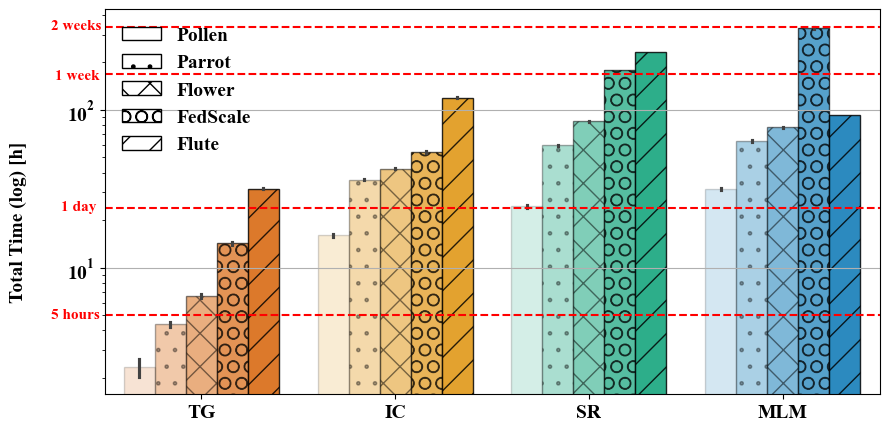

In [36]:
# Drawing bar plots for each dataset, hardware setting = 2 and 100 clients per round
current_hardware_setting = 2
n_clients_per_round = 100
dfs: List[pd.DataFrame] = []
for framework in FRAMEWORKS:
    for dataset in DATASETS:
        random.seed(1337)
        tmp_table = results_table.filter(pc.field('framework') == pc.scalar(framework)).filter(pc.field('dataset') == pc.scalar(dataset)).filter(pc.field('hardware_setting') == pc.scalar(current_hardware_setting)).filter(pc.field('n_clients_per_round') == pc.scalar(n_clients_per_round)).filter(pc.field('is_dropped') == pc.scalar(False))
        try:
            if tmp_table.num_rows != 0:
                tmp_rct = tmp_table.column('rct').to_numpy()[1:].astype('timedelta64[s]').astype(float)
                tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                tmp_dict = {
                    'Round Completion Time [s]': tmp_rct,
                    'Round Completion Time [m]': np.array(tmp_rct)*(1/60),
                    'Round Completion Time [h]': np.array(tmp_rct)*(1/3600),
                    'Framework': [framework]*N_TOTAL_ROUNDS,
                    'Dataset': [dataset]*N_TOTAL_ROUNDS,
                }
                log(INFO, f"For {framework} and {dataset} the mean RCT (100 clients) is {np.mean(tmp_rct)}+-{np.std(tmp_rct)}")
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
        except Exception as e:
            print(e)
df = pd.concat(dfs)
alpha_split = 1.0/(len(df['Framework'].unique())+1)
alphas = [alpha_split*(i+1) for i in range(len(df['Framework'].unique()))]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Dataset',
    y='Round Completion Time [h]',
    order=DATASETS,
    hue='Framework',
    hue_order=FRAMEWORKS,
    errorbar=error_bar_fn_std_based,
    # errorbar=error_bar_fn_min_max,
    estimator=np.sum,
    ax=ax,
    edgecolor='black',
    )
split = (len(df['Framework'].unique())*len(df['Dataset'].unique())-1)
for i, patch in enumerate(ax.patches):
    if i > split:
        patch.set_facecolor('w')
        patch.set_hatch(TEXTURES[(i-split-1)%len(TEXTURES)])
        patch.set_alpha(1.0)
    else:
        patch.set_facecolor(COLORS[i%(len(df['Dataset'].unique()))])
        patch.set_hatch(TEXTURES[i//(len(df['Dataset'].unique()))])
        patch.set_alpha(alphas[i//(len(df['Dataset'].unique()))])
y_axis_position = plt.gca().get_position().x0
plt.axhline(y=5, color='r', linestyle='--')
plt.text(y_axis_position-0.9, 4.8, '5 hours', color='r', fontsize=11)
plt.axhline(y=24, color='r', linestyle='--')
plt.text(y_axis_position-0.85, 23, '1 day', color='r', fontsize=11)
plt.axhline(y=24*7, color='r', linestyle='--')
plt.text(y_axis_position-0.88, (24*7) - 12, '1 week', color='r', fontsize=11)
plt.axhline(y=24*14, color='r', linestyle='--')
plt.text(y_axis_position-0.9, (24*14) - 14, '2 weeks', color='r', fontsize=11)
y_label = plt.ylabel('Total Time (log) [h]')
y_label.set_weight('bold')
plt.xlabel('')
ax.yaxis.set_label_coords(-0.1, 0.45)
plt.yscale('log')
plt.legend().set_title('')
legend_rect = plt.legend(loc='upper left').get_frame()
legend_rect.set_alpha(0)
plt.grid(axis='y')
plt.savefig('inv_frameworks_multinode.pdf', format="pdf", dpi=800, bbox_inches='tight')
plt.savefig('inv_frameworks_multinode.png', format="png", dpi=800, bbox_inches='tight')
plt.show()